# A Regressão Linear
- Se temos um conjunto de pontos como o mostrado abaixo, podemos traçar qualquer reta que passa por esses pontos
    - Nesse caso, vamos traçar uma reta y = x

<img width='400px' src='https://imgur.com/amSoj0T.png'>

- Infinitas retas podem ser traçadas, mas qual seria <font color='blue'>**a melhor reta**</font> que passa por esses pontos?


<img width='400px' src='https://imgur.com/uMJXTMY.png'>



- <font color='blue'>**a melhor reta:**</font> o que seria "melhor"?

    - Para definir esse conceito podemos, por exemplo, verificar a distância de cada ponto a essa reta vermelha e escolher baseado nessa distância

<img width='400px' src='https://imgur.com/b67bbnF.png'>


- A **regressão vai traçar essa reta de forma a <font color='blue'>minimizar a soma dos erros ao quadrado**</font>, segundo a própria documentação
    - https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares
    
<img width='400px' src='https://imgur.com/K4fXZZw.png'>




In [1]:
# Podemos considerar esses dados abaixo
import pandas as pd

dados = pd.DataFrame({
    'X': [1,2,3,4,5],
    'Y': [1.3,1.8,3.5,4,4.6]
})

dados.head(2)

,X,Y
0,1,1.3
1,2,1.8


In [2]:
dados.head(5)

,X,Y
0,1,1.3
1,2,1.8
2,3,3.5
3,4,4.0
4,5,4.6


In [3]:
# Criaremos uma reta em que y = x, então podemos escrever o y_reta como
dados['Y_reta'] = dados.X

In [4]:
dados.head(4)

,X,Y,Y_reta
0,1,1.3,1
1,2,1.8,2
2,3,3.5,3
3,4,4.0,4


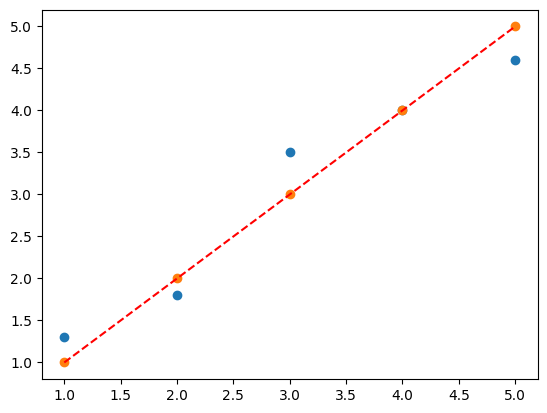

In [5]:
# Visualizando esses pontos graficamente, podemos traçar uma reta que passa por esse pontos
import matplotlib.pyplot as plt

fig,ax = plt.subplots()

ax.scatter(dados.X,dados.Y)
ax.plot(dados.X,dados.Y_reta,'--r')
ax.scatter(dados.X,dados.Y_reta)

plt.show()

In [6]:
dados['Y_reta'] = dados.X

- **Vamos usar a regressão linear para traçar a melhor reta que passa por esses pontos**
    - https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression

In [7]:
# Importando a regressão linear
from sklearn.linear_model import LinearRegression

In [8]:
dados.X

,X
0,1
1,2
2,3
3,4
4,5


In [9]:
# Criando o regressor
reg = LinearRegression().fit(dados.X.values.reshape(-1,1),dados.Y)

In [10]:
# Visualizando o coeficiente angular
a = reg.coef_[0]

In [11]:
# o coeficiente linear
b = reg.intercept_

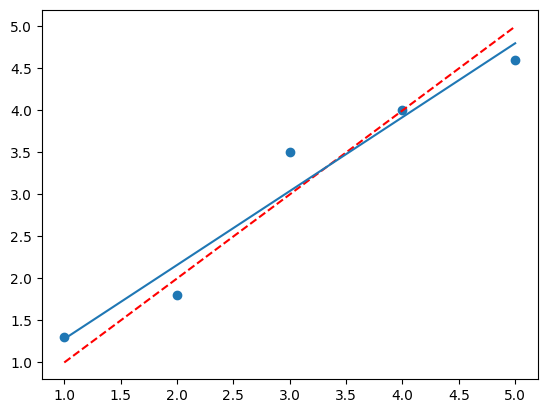

In [12]:
# Visualizando graficamente
fig,ax = plt.subplots()

ax.scatter(dados.X,dados.Y)
ax.plot(dados.X,dados.Y_reta,'--r')

x = dados.X.values
y = a*x + b
ax.plot(x,y)

plt.show()

In [13]:
# Fazendo a previsão e adicionando na base
dados['Y_pred'] = reg.predict(dados.X.values.reshape(-1,1))

In [14]:
dados

,X,Y,Y_reta,Y_pred
0,1,1.3,1,1.28
1,2,1.8,2,2.16
2,3,3.5,3,3.04
3,4,4.0,4,3.92
4,5,4.6,5,4.80


In [15]:
# Calculando o erro da reta vermelha e da regressão
dados['erro_reta'] = (dados.Y - dados.Y_reta)**2
dados['erro_pred'] = (dados.Y - dados.Y_pred)**2

In [16]:
# Verificando essa base e a soma do erro
dados[['erro_reta','erro_pred']].mean()

,0
erro_reta,0.1080
erro_pred,0.0776


- Pdemos utilizar o erro médio absoluto e o erro médio quadrático do próprio scikit-learn para calcular esses erros
    - https://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics

In [17]:
# Além disso, também podemos usar o erro médio absoluto e o erro médio quadrático do próprio scikit-learn

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [18]:
# Visualizando o resultado da previsão
print(mean_absolute_error(dados.Y,dados.Y_reta))
print(mean_squared_error(dados.Y,dados.Y_reta))
print(mean_absolute_error(dados.Y,dados.Y_pred))
print(mean_squared_error(dados.Y,dados.Y_pred))

0.2800000000000001
0.10800000000000005
0.22400000000000003
0.07760000000000003


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Usando a Regressão Linear de forma prática
- **Vamos utilizar o dataset de fertilidade vs taxa de emprego, disponível no AVA**
  

In [20]:
# Importando o dataset para um data frame
df_work =  pd.read_csv("/content/SLR2.csv")

In [21]:
# Visualizando o dataframe
df_work

,fertility rate,worker percent
0,3.71,28.33
1,3.59,28.72
2,3.48,29.18
3,3.37,29.67
4,3.27,30.17
5,3.17,30.66
6,3.07,31.02
7,2.97,31.40
8,2.88,31.77
9,2.78,32.13


# Exercício
- **Regressão Linear Simples**


- **Separe as variáveis dependente (resposta) e independente (preditora) **

In [25]:
# Definindo o predictor
X = df_work[['fertility rate']]

# Definindo a resposta
y = df_work['worker percent']

# Visualizando as primeiras entradas
X.head(3)
y.head(3)

,worker percent
0,28.33
1,28.72
2,29.18


In [27]:
# Definindo o predictor
X = df_work['fertility rate'].values.reshape(-1, 1)
# Definindo a resposta
y = df_work['worker percent']

# Visualizando as primeiras entradas
print(X[:5])
print(y[:5])


[[3.71]
 [3.59]
 [3.48]
 [3.37]
 [3.27]]
0    28.33
1    28.72
2    29.18
3    29.67
4    30.17
Name: worker percent, dtype: float64


- Separando nossa base em treino e teste para criarmos o modelo
    - https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


- **Separe a base em treio e teste**

- **Aplique a regressão linear**

In [31]:
# Criando o regressor
reg = LinearRegression()

# Treinando o modelo
reg.fit(X_train, y_train)

# Fazendo a previsão
y_pred = reg.predict(X_test)


In [32]:
from sklearn.linear_model import LinearRegression

# Criando e treinando o regressor
reg = LinearRegression().fit(X_train, y_train)

# Coeficientes
a = reg.coef_[0]
b = reg.intercept_

print(f"Coeficiente angular (a): {a}")
print(f"Coeficiente linear (b): {b}")


Coeficiente angular (a): -8.594312559627317
Coeficiente linear (b): 57.54420316556403


- **Avalie o erro**

In [33]:
# Fazendo previsões
y_pred = reg.predict(X_test)

# Calculando o erro médio absoluto e o erro médio quadrático
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Erro Médio Absoluto (MAE): {mae}")
print(f"Erro Médio Quadrático (MSE): {mse}")


Erro Médio Absoluto (MAE): 1.722213185416537
Erro Médio Quadrático (MSE): 3.3797445929731933


- **Visualize graficamente y_teste e y_pred**

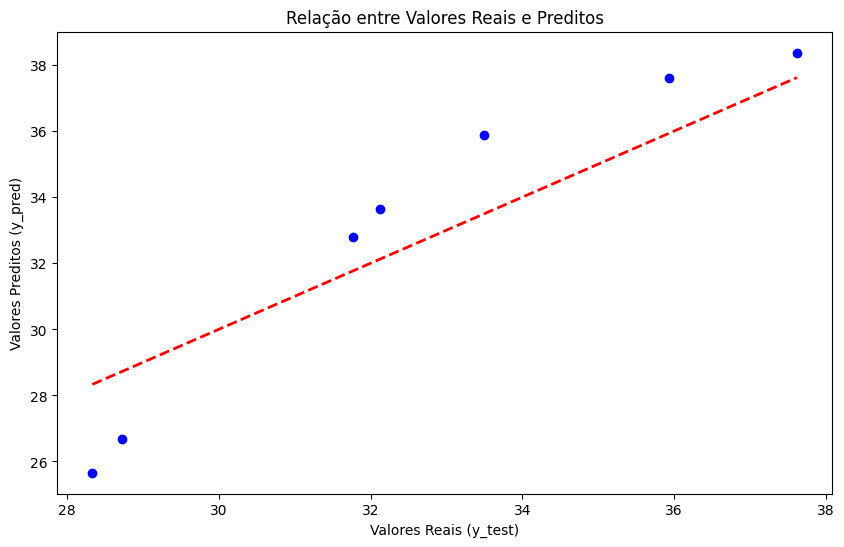

In [34]:
# Visualizando a relação do y_test com o y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Valores Reais (y_test)')
plt.ylabel('Valores Preditos (y_pred)')
plt.title('Relação entre Valores Reais e Preditos')
plt.show()


- **Brinde: o método score**
#### Basicamente, mostra o quão precisa é sua linha de regressão quando comparada à média.

Erro Médio Absoluto (MAE) da Média: 2.6689795918367336
Erro Médio Quadrático (MSE) da Média: 10.193991836734691


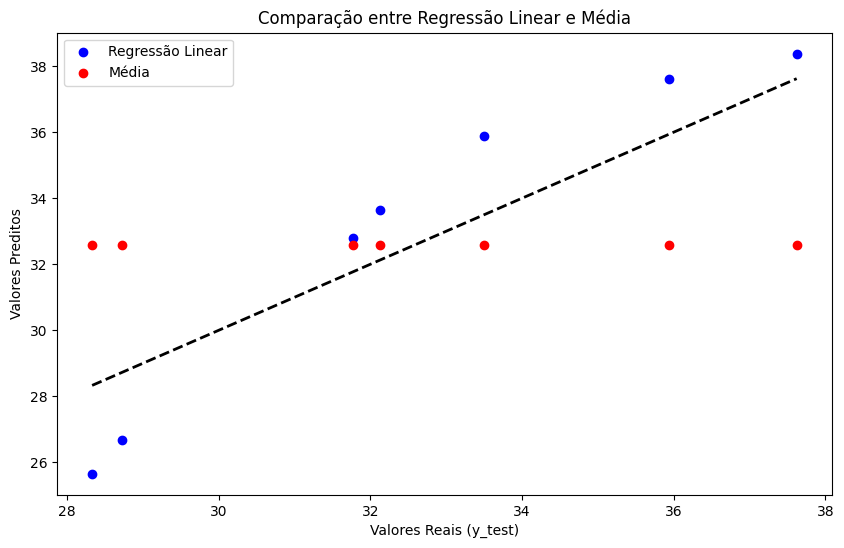

In [36]:
import matplotlib.pyplot as plt
# Calculando a média de y_test
y_mean = [y_test.mean()] * len(y_test)

# Erro médio absoluto e erro médio quadrático para a média
mae_mean = mean_absolute_error(y_test, y_mean)
mse_mean = mean_squared_error(y_test, y_mean)

print(f"Erro Médio Absoluto (MAE) da Média: {mae_mean}")
print(f"Erro Médio Quadrático (MSE) da Média: {mse_mean}")

# Visualizando a comparação
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Regressão Linear')
plt.scatter(y_test, y_mean, color='red', label='Média')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--k', linewidth=2)
plt.xlabel('Valores Reais (y_test)')
plt.ylabel('Valores Preditos')
plt.title('Comparação entre Regressão Linear e Média')
plt.legend()
plt.show()
